# Phase 1: Supervised Learning

## Model 1: Random Forest

### **Project Integration**
We are training this model to predict liver disease based on patient features. These predictions directly inform the foundational advice system, determining whether to trigger a **“Consult a hepatologist”** recommendation or a **“Routine check-up”** suggestion.

---

### **1. Model Selection Rationale**

* **Handling Non-linear Medical Data:** Medical biomarkers like Bilirubin and Liver Enzymes often have non-linear relationships with disease; Random Forest captures these "threshold" patterns more effectively than linear models.
* **Ensemble Robustness:** By aggregating results from multiple decision trees, Random Forest significantly reduces the risk of overfitting, which is critical when working with relatively small datasets (~583 rows).
* **Feature Interpretability:** This model provides "Feature Importance" scores, allowing us to justify the advice system's output (e.g., explaining why a high Alamine Aminotransferase level triggered a "Consult a specialist" recommendation).
* **Minimal Data Scaling:** While we applied scaling for consistency across team models, Random Forest is naturally robust against the wide numerical ranges found in medical lab results.

#### **Strengths**
* **Robust to Noise:** Effectively handles outliers in medical lab results.
* **High Predictive Power:** Captures complex interactions between different liver enzymes.
* **Internal Validation:** Uses bagging to provide a stable estimate of error.

#### **Weaknesses**
* **Complexity:** More difficult to visualize than a single Decision Tree or Logistic Regression.
* **Memory Usage:** Can become computationally expensive if the number of trees ($n\_estimators$) is too high.


**Data Preprocessing & Splitting**
In this stage, we load the preprocessed medical data and handle the final formatting required for the Random Forest algorithm. We use a **stratified split** to maintain the ratio of liver disease cases across our training and testing sets, ensuring a reliable evaluation of the model's performance on the minority class.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("preprocessed_data.csv")

# Features and target
X = df.drop("Dataset", axis=1)
y = df["Dataset"]

# Aligning labels for binary classification (0 and 1)
y = y.replace({1: 0, 2: 1})

# Train-test split (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Hyperparameter Tuning via GridSearchCV**
To refine the system for meaningful medical predictions, we perform a grid search over key hyperparameters such as `n_estimators` and `max_depth`. We use **5-fold cross-validation** and optimize for the **F1-Score** to ensure the model maintains a scientific balance between precision and recall, reducing the risk of overfitting on the training data.

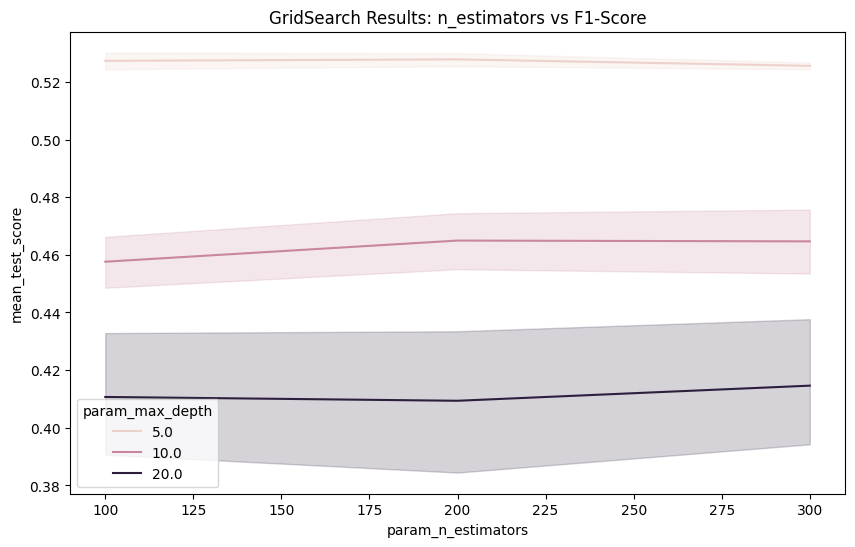

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# GridSearchCV to refine the system
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_



### **Final Evaluation & Decision Thresholding**
In this final stage, we evaluate the optimized model's performance on the unseen test set. To prioritize medical safety, we manually adjust the **decision threshold to 0.35**, shifting the model’s focus toward **Recall**. This ensures the system is highly sensitive to liver disease cases, which is critical for an advice system suggesting specialist consultations. All final metrics, feature importance rankings, and ROC curves are saved to the project directories for documentation.

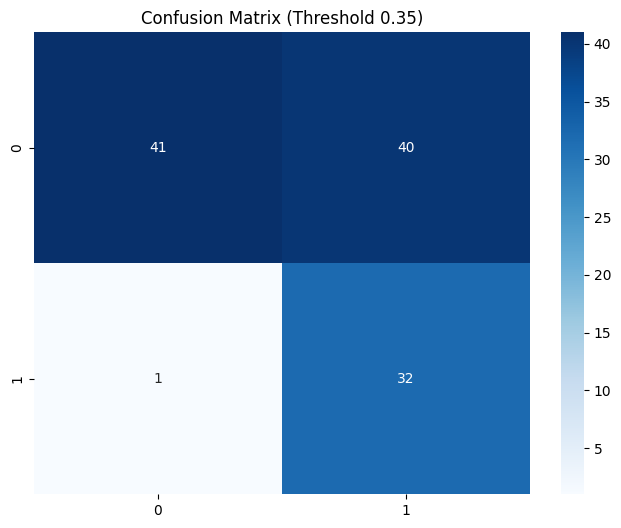

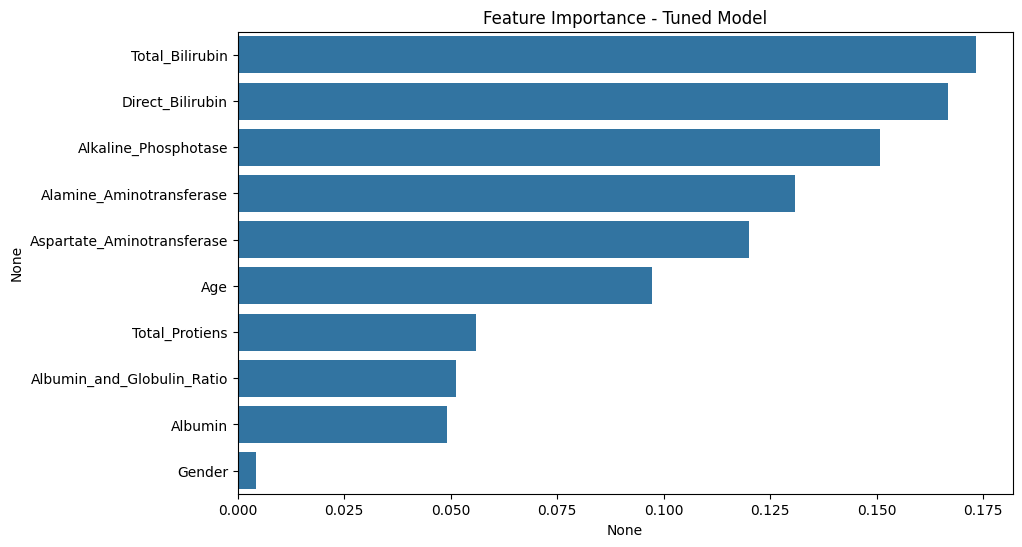

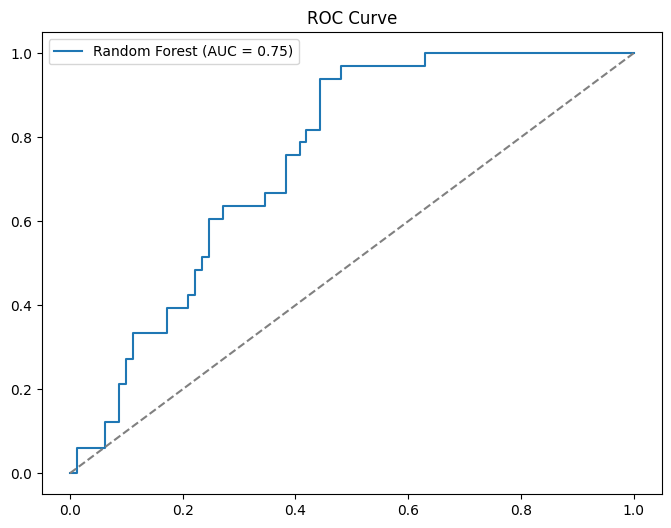

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
import joblib

# 1. Predictions with fixed 0.35 threshold for high recall
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]
threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

# 2. Save Model & Numerical results
joblib.dump(best_rf, 'Supervised_Learning/models/best_rf_model.pkl')

cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='f1')
report = classification_report(y_test, y_pred)

with open('Supervised_Learning/evaluation_results/rf_results.txt', 'w') as f:
    f.write(f"Best Parameters: {grid_rf.best_params_}\n")
    f.write(f"5-Fold CV F1 Score: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}\n")
    f.write("-" * 30 + "\n")
    f.write(report)

# 3. Save Visual Plots
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Threshold {threshold})")
plt.savefig('Supervised_Learning/plots/rf_confusion_matrix.png')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importance - Tuned Model")
plt.savefig('Supervised_Learning/plots/rf_feature_importance.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curve")
plt.legend()
plt.savefig('Supervised_Learning/plots/rf_roc_curve.png')
plt.show()

# Model 2 : Logistic Regression

## 1️⃣ Model Selection Rationale

### Why Logistic Regression?
* **Suitable for binary classification:** Specifically for predicting liver disease vs. no disease.
* **Handles small-to-medium datasets:** Works effectively with tabular data like the Indian Liver Patient Records (~583 rows).
* **Interpretable coefficients:** Provides clear insights into how each medical feature impacts the diagnosis.
* **Strong baseline model:** Serves as a perfect point of comparison for more complex models like Random Forest.
* **Efficiency:** Extremely fast to train and deploy.

### ✅ Strengths
* **High Interpretability:** The model's coefficients directly show the impact of each feature.
* **Low Computational Cost:** Requires very little memory and processing power.
* **Linear Relationships:** Performs exceptionally well when the relationship between features is approximately linear.
* **Probability Outputs:** It doesn't just classify; it gives a probability score which is vital for medical risk prediction.
* **Robustness:** Less prone to overfitting on smaller datasets compared to deep trees.

### ❌ Weaknesses
* **Linear Assumption:** It assumes a linear relationship between the features and the log-odds of the outcome.
* **Complexity Issues:** Might struggle with highly complex, non-linear patterns in medical data.
* **Multicollinearity:** It is sensitive to features that are highly correlated with each other.
* **Requirement for Scaling:** Needs proper feature scaling (like StandardScaler) to achieve optimal performance.
  

# Logistic Regression Data Preparation
This section prepares the dataset for training a Logistic Regression model. 
It includes loading data, splitting into features and target, train-test split, and feature scaling.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import joblib

# ---------------------------------------------
# 1️⃣ Load the dataset
# ---------------------------------------------
df = pd.read_csv("preprocessed_data.csv")

# ---------------------------------------------
# 2️⃣ Separate features (X) from the target variable (y)
# "Dataset" column is assumed to be the target.
# ---------------------------------------------
X = df.drop("Dataset", axis=1)
y = df["Dataset"]

# ---------------------------------------------
# 3️⃣ Split the data into training and testing sets
# 80% training, 20% testing, with stratification to maintain class distribution
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------
# 4️⃣ Feature Scaling
# Logistic Regression is sensitive to feature scales.
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
# ---------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data is ready and scaled!")

# Logistic Regression Model Building
This section demonstrates building, training, and predicting with a Logistic Regression model for binary classification.

In [ ]:
# Importing the necessary library
from sklearn.linear_model import LogisticRegression

# ------------------------------
# Step 1: Initialize the model
# ------------------------------
# Setting random_state for reproducibility and max_iter to ensure convergence
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# ------------------------------
# Step 2: Train the model
# ------------------------------
# Fitting the model on scaled training features and corresponding labels
log_reg.fit(X_train_scaled, y_train)

# ------------------------------
# Step 3: Make predictions
# ------------------------------
# Predict class labels for test set
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities for the positive class
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# ------------------------------
# Step 4: Confirmation message
# ------------------------------
print("Logistic Regression Model Trained Successfully!")

#  Logistic Regression Evaluation
This section evaluates the trained Logistic Regression model using key metrics, plots, cross-validation, and saves the model for future use.

In [ ]:
from sklearn.model_selection import cross_val_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd

# ==========================================
# 1. COMPREHENSIVE EVALUATION
# ==========================================
# Evaluate the Logistic Regression model using classification metrics, confusion matrix, and ROC curve

# Generate and print classification report
print("Logistic Regression Classification Report:\n")
lr_report = classification_report(y_test, y_pred)  
print(lr_report)

# Plot and save Confusion Matrix as heatmap
plt.figure(figsize=(6,4))
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('Supervised_Learning/evaluation_results/lr_confusion_matrix.png')
plt.show()

# Plot and save ROC-AUC curve
# Specify pos_label=2 because y_test contains {1,2} 
lr_roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LR (AUC = {lr_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png')
plt.show()

# ==========================================
# 2. K-FOLD CROSS-VALIDATION (k=5)
# ==========================================
# Assess model generalization using 5-fold cross-validation on training data
cv_f1_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"5-Fold Cross-Validation F1 Score: {cv_f1_scores.mean():.3f} ± {cv_f1_scores.std():.3f}")

# ==========================================
# 3. MODEL PERSISTENCE & DELIVERABLES
# ==========================================
# Save trained model and scaler for future predictions or deployment
joblib.dump(log_reg, 'Supervised_Learning/models/logistic_regression_model.pkl')
joblib.dump(scaler, 'Supervised_Learning/models/lr_scaler.pkl')

# Export classification metrics to CSV for documentation and reporting
report_dict = classification_report(y_test, y_pred, output_dict=True)
pd.DataFrame(report_dict).transpose().to_csv('Supervised_Learning/evaluation_results/lr_metrics_report.csv')

print("\n All evaluation metrics generated, visualizations saved, and model exported successfully!")